In [73]:
import glob
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import scipy as sp
from calibration import lifetime_to_temperature_water_gel13, pict_calibration, lifetime_to_temperature_201112
from scipy.optimize import curve_fit
from matplotlib.backends.backend_pdf import PdfPages

In [74]:
path = './liposome/Fig3f_liposome.csv'
df = pd.read_csv(path, header = None)
averaged_liposome = 0
data_set_liposome = pd.DataFrame()

for column in df:
    deltaT = -np.log(df[column])/0.0229
    deltaT= np.array(deltaT[34:234])
    averaged_liposome += deltaT
    data_set_liposome = pd.concat([data_set_liposome, pd.DataFrame(deltaT)], axis = 1)
    
averaged_liposome = pd.DataFrame(averaged_liposome/df.shape[1])[0]

#データの保存
data_set_liposome.to_csv('liposome_all.csv')

In [75]:
file_path = glob.glob('./cyto/22041*_relaxation_lin22.6_24deg_150mW/*.csv')
file_path.sort()

In [76]:
#t=0で切り取る
average_normal = 0
data_set_cyto = pd.DataFrame()

for path in file_path:
    data = np.float32(pd.read_csv(path, sep = '\t').iloc[1:, 3])
    diff = (pd.DataFrame(data) - pd.DataFrame(data[1:]))[0]
    index = np.argmax(diff)
    temperature = lifetime_to_temperature_201112(np.float32(pd.read_csv(path, sep = '\t').iloc[1:, 1]))[index-100: index+100]
    average_normal += temperature
    data_set_cyto = pd.concat([data_set_cyto, pd.DataFrame(temperature)], axis = 1)
    
average_normal = average_normal/len(file_path)
average_normal = average_normal - np.mean(average_normal[:10])

#データの保存
(data_set_cyto - data_set_cyto.iloc[:10, :].mean()).to_csv('cyto_all.csv')

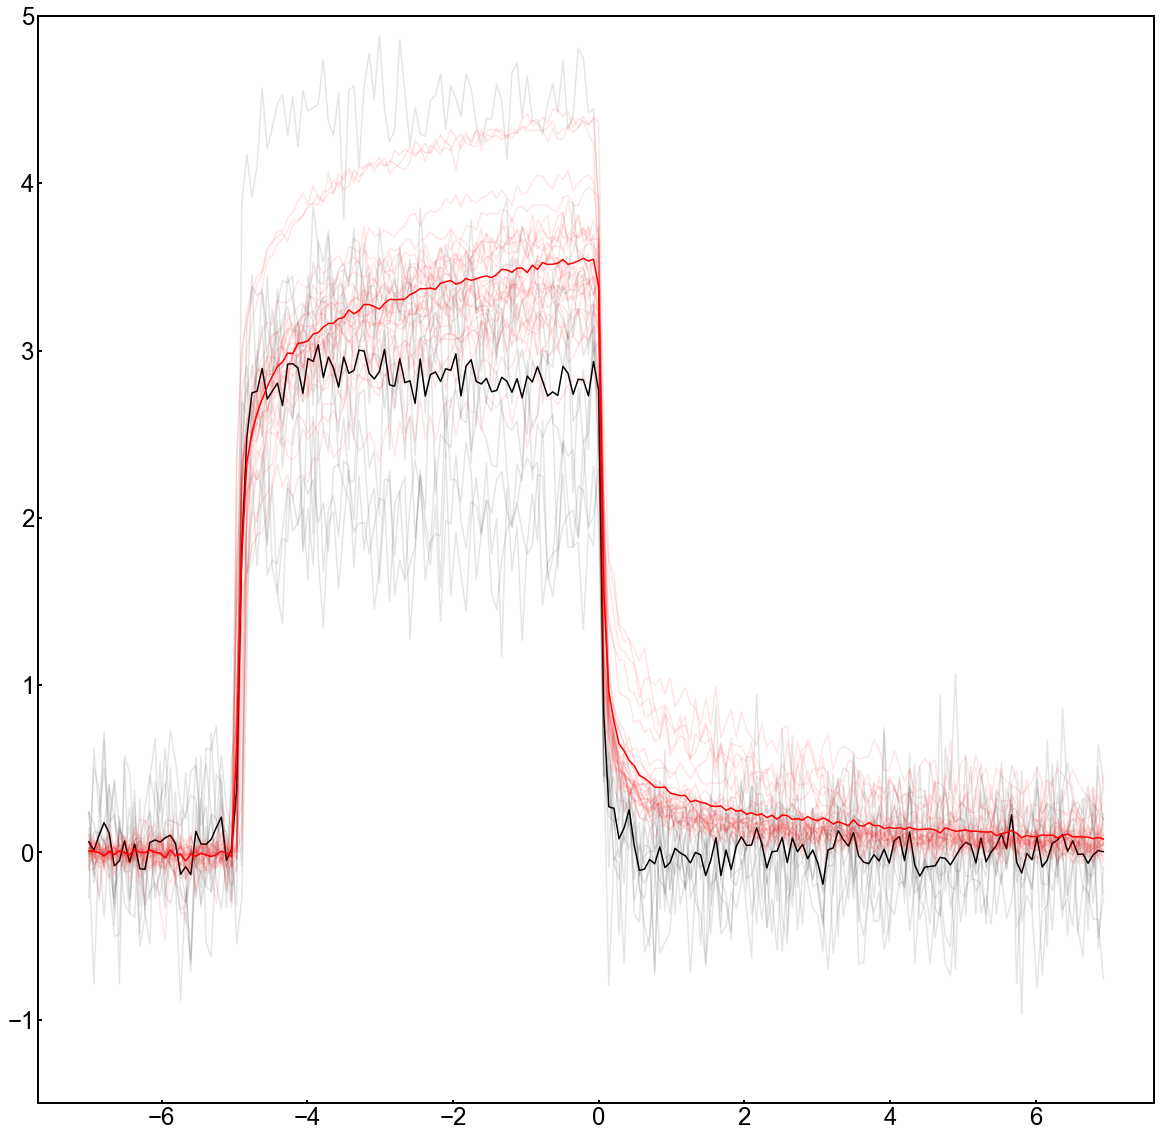

In [77]:
fig = plt.figure(figsize = (20, 20))
plt.rcParams['font.family'] = 'Arial'
plt.rcParams['xtick.major.width'] = 2.0
plt.rcParams['ytick.major.width'] = 2.0
plt.rcParams['axes.linewidth'] = 2.0
plt.tick_params(axis='both', direction = "in", labelsize = 24)

time = [0.07*(i-100) for i in range(len(averaged_liposome))]
plt.plot(time, averaged_liposome, color = 'black')
plt.plot(time, data_set_liposome, color = 'black', alpha = 0.1)
plt.plot(time, average_normal, color = 'red')
plt.plot(time, data_set_cyto - data_set_cyto.iloc[:10, :].mean(), color = 'red', alpha = 0.1)

plt.ylim(-1.5, 5)
plt.show()

#pdfのセーブ
pp = PdfPages('./Fig3f_outline.pdf')
pp.savefig(fig)
pp.close()

#データの保存
pd.DataFrame(averaged_liposome).to_csv('liposome.csv')
pd.DataFrame(average_normal).to_csv('cyto.csv')

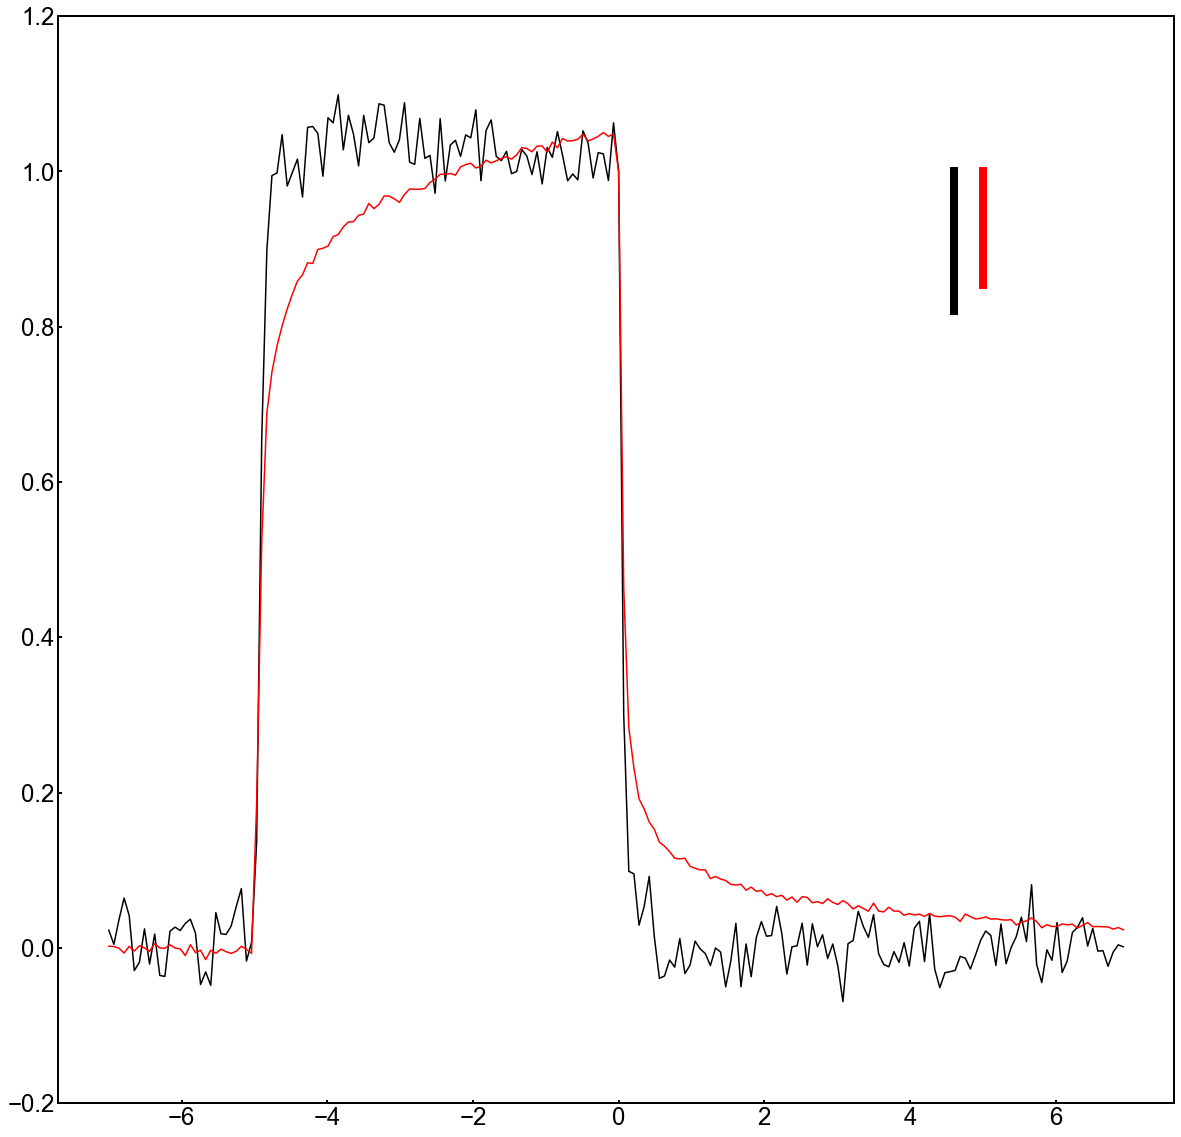

In [78]:
fig = plt.figure(figsize = (20, 20))
plt.rcParams['font.family'] = 'Arial'
plt.rcParams['xtick.major.width'] = 2.0
plt.rcParams['ytick.major.width'] = 2.0
plt.rcParams['axes.linewidth'] = 2.0
plt.tick_params(axis='both', direction = "in", labelsize = 24)

time = [0.07*(i-100) for i in range(len(averaged_liposome))]
plt.plot(time, averaged_liposome/averaged_liposome[100], color = 'black')
plt.plot(time, average_normal/average_normal[100], color = 'red')
plt.ylim(-0.2, 1.2)

#1˚Cを示すバーを挿入
liposome_bar = [1- 0.5/averaged_liposome[100]*i/100 for i in range(100)]
liposome_bar_pos = [4.6 for i in range(len(liposome_bar))]
plt.plot(liposome_bar_pos, liposome_bar, linewidth = 8, color = 'black', linestyle = '-')

#1˚Cを示すバーを挿入
normal_bar = [1- 0.5/average_normal[100]*i/100 for i in range(100)]
normal_bar_pos = [5.0 for i in range(len(normal_bar))]
plt.plot(normal_bar_pos, normal_bar, linewidth = 8, color = 'red', linestyle = '-')
plt.show()


#pdfのセーブ
pp = PdfPages('./Fig3f_outline_normalized.pdf')
pp.savefig(fig)
pp.close()

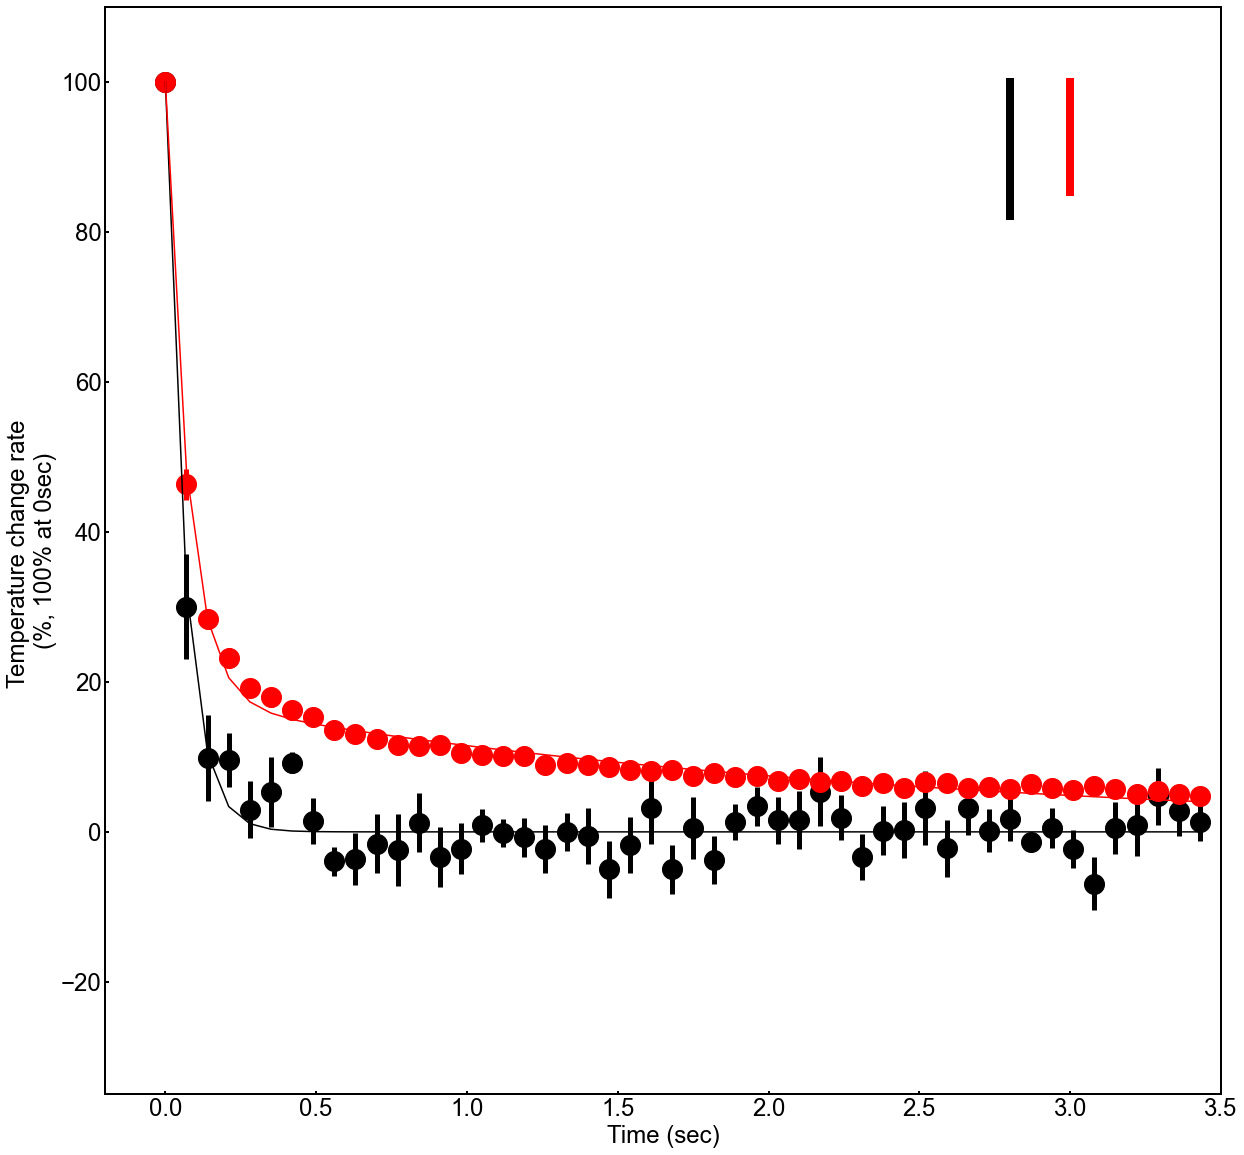

In [79]:
fig = plt.figure(figsize=(20, 20))
plt.rcParams['font.family'] = 'Arial'
plt.rcParams['xtick.major.width'] = 2.0
plt.rcParams['ytick.major.width'] = 2.0
plt.rcParams['axes.linewidth'] = 2.0
plt.tick_params(axis='both', direction = "in", labelsize = 24)


#SEMの計算
data_set_cyto = data_set_cyto - np.mean(data_set_cyto.iloc[:10, :])
data_set_cyto = data_set_cyto/data_set_cyto.iloc[100, :]*100
sem_cyto = data_set_cyto.sem(axis = 1)

data_set_liposome = data_set_liposome/data_set_liposome.iloc[100, :]*100
sem_liposome = data_set_liposome.sem(axis = 1)


#1˚Cを示すバーを挿入
liposome_bar = [100- 50/averaged_liposome[100]*i/100 for i in range(100)]
liposome_bar_pos = [2.8 for i in range(len(liposome_bar))]
plt.plot(liposome_bar_pos, liposome_bar, linewidth = 8, color = 'black', linestyle = '-')

#1˚Cを示すバーを挿入
normal_bar = [100- 50/average_normal[100]*i/100 for i in range(100)]
normal_bar_pos = [3.0 for i in range(len(normal_bar))]
plt.plot(normal_bar_pos, normal_bar, linewidth = 8, color = 'red', linestyle = '-')



time = [i*0.07 for i in range(len(averaged_liposome[100:]))]
plt.errorbar(time[:50], averaged_liposome[100:150]*100/averaged_liposome[100], yerr = np.ravel(sem_liposome)[100:150], capsize=0, fmt='o', markersize=0, linewidth = 5, ecolor='black')
plt.errorbar(time[:50], average_normal[100:150]*100/average_normal[100], yerr = np.ravel(sem_cyto)[100:150], capsize=0, fmt='o', markersize=0, linewidth = 5, ecolor='red')
plt.plot(time[:50], averaged_liposome[100:150]*100/averaged_liposome[100], color = 'black', markersize = 20, marker = 'o', linewidth = 0)
plt.plot(time[:50], average_normal[100:150]*100/average_normal[100], color = 'red', markersize = 20, marker = 'o', linewidth = 0)
plt.xlim(-0.2, 3.5)
plt.ylim(-35, 110)
plt.xlabel('Time (sec)', fontsize = 24)
plt.ylabel('Temperature change rate \n(%, 100% at 0sec)', fontsize = 24)


#温度緩和の時定数の計算
def relaxation(time, ratio, t1, t2):
    return ratio*np.exp(-time/t1) + (1-ratio)*np.exp(-time/t2)

def relaxation_liposome(time, t1):
    return np.exp(-time/t1)

result_liposome = curve_fit(relaxation_liposome, time[:50], averaged_liposome[100:150]/averaged_liposome[100])[0]
result_5sec = curve_fit(relaxation, time[:50], average_normal[100:150]/average_normal[100])[0]

#fitting結果の図示
plt.plot(time[:50], relaxation_liposome(np.ravel(time[:50]), result_liposome[0])*100, color = 'black')
plt.plot(time[:50], relaxation(np.ravel(time[:50]), result_5sec[0], result_5sec[1], result_5sec[2])*100, color = 'red')



#pdfのセーブ
pp = PdfPages('./Fig3f_ralaxation.pdf')
pp.savefig(fig)
pp.close()


#データの保存
pd.DataFrame(averaged_liposome[100:150]*100/averaged_liposome[100]).to_csv('liposome_normalized.csv')
pd.DataFrame(average_normal[100:150]*100/average_normal[100]).to_csv('cyto_normalized.csv')
pd.DataFrame(sem_liposome[100:150]).to_csv('sem_liposome.csv')
pd.DataFrame(sem_cyto[100:150]).to_csv('sem_cyto.csv')

In [80]:
#welchのt検定
sum_cyto = data_set_cyto.iloc[102:150].sum().values
sum_liposome = data_set_liposome.iloc[102:150].sum().values
sp.stats.ttest_ind(sum_cyto, sum_liposome, equal_var = False)

Ttest_indResult(statistic=6.717850531568668, pvalue=1.0731409204459907e-06)

In [81]:
sem_cyto_bar = (sum_cyto*0.07).std(ddof = 1)/np.sqrt(len(sum_cyto))
sem_liposome_bar = (sum_liposome*0.07).std(ddof = 1)/np.sqrt(len(sum_liposome))

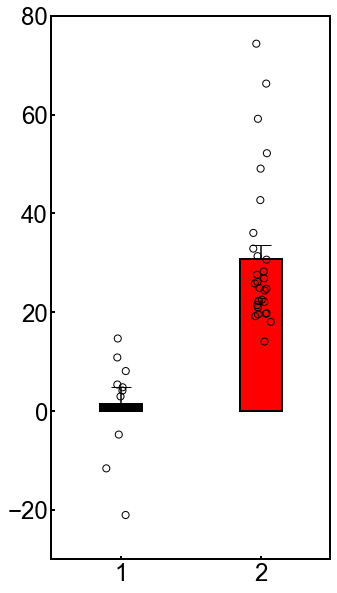

In [82]:
fig = plt.figure(figsize = (5, 10))
plt.tick_params(axis='both', direction = "in", labelsize = 24)
sum_cyto_ave = np.average(sum_cyto*0.07)
sum_liposome_ave = np.average(sum_liposome*0.07)

plt.bar(2, sum_cyto_ave, yerr = [[0], [sem_cyto_bar]], capsize = 10, ecolor = 'black', width=0.3, color=(1, 0, 0, 1), edgecolor='black', linewidth = 2, zorder = 1)
x = np.random.normal(2, 0.03, size=len(sum_cyto)) 
plt.scatter(x, sum_cyto*0.07, color='none', edgecolor='black', alpha = 1, s=50, zorder = 2)
plt.bar(1, sum_liposome_ave, yerr = [[0], [sem_liposome_bar]], capsize = 10, ecolor = 'black', width=0.3, color=(0, 0, 0, 1), edgecolor='black', linewidth = 2, zorder = 1)
x = np.random.normal(1, 0.03, size=len(sum_liposome)) 
plt.scatter(x, sum_liposome*0.07, color='none', edgecolor='black', alpha = 1, s=50, zorder = 2)


plt.ylim(-30, 80)
plt.xlim(0.5, 2.5)

#pdfのセーブ
pp = PdfPages('./Fig3f_ralaxation_bar.pdf')
pp.savefig(fig)
pp.close()

#データの保存
pd.DataFrame(sum_cyto*0.07).to_csv('AUC_cyto_all.csv')
pd.DataFrame(sum_liposome*0.07).to_csv('AUC_liposome_all.csv')

In [83]:
print(sum_cyto_ave)
print(sem_cyto_bar)
print(sum_liposome_ave)
print(sem_liposome_bar)

30.837505
2.740588311200304
1.3512032484247318
3.42850679665925
